<a href="https://colab.research.google.com/github/Phalguni-dhabale/MV-LAB/blob/main/MV_TAE_PBL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install opencv-python numpy matplotlib scikit-image


In [8]:

!pip install opencv-contrib-python

Re-applying dehazing algorithm with guided filter...
Consider installing 'opencv-contrib-python' for better results.


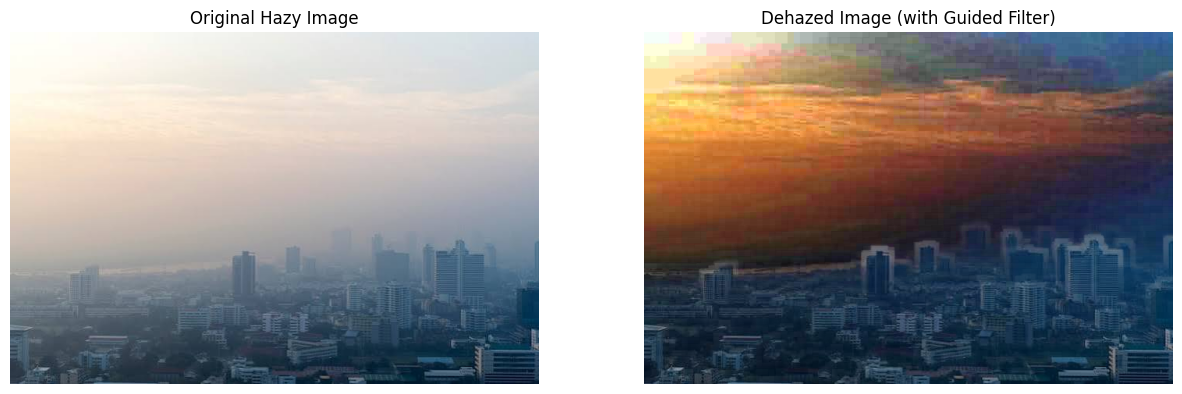

In [9]:
if hazy_image is not None:
    print("Re-applying dehazing algorithm with guided filter...")
    dehazed_image = dehaze_image(hazy_image)

    if dehazed_image is not None:
        plt.figure(figsize=(15, 7))

        plt.subplot(1, 2, 1)
        plt.imshow(hazy_image)
        plt.title('Original Hazy Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(dehazed_image)
        plt.title('Dehazed Image (with Guided Filter)')
        plt.axis('off')

        plt.show()
    else:
        print("Dehazing failed. Please ensure the image was loaded correctly.")
else:
    print("Cannot proceed with dehazing as no image was loaded.")

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import exposure

print("Libraries imported successfully.")

Libraries imported successfully.


Saving hazy_city.jpg to hazy_city.jpg
Image 'hazy_city.jpg' loaded successfully. Shape: (452, 678, 3)


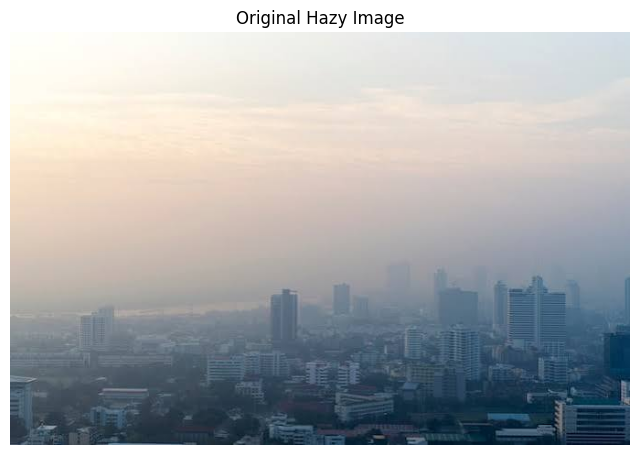

In [6]:

from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
try:
    hazy_image = cv2.imread(image_path)
    if hazy_image is None:
        raise FileNotFoundError(f"Image not found at {image_path}")
    hazy_image = cv2.cvtColor(hazy_image, cv2.COLOR_BGR2RGB)
    print(f"Image '{image_path}' loaded successfully. Shape: {hazy_image.shape}")

    plt.figure(figsize=(8, 6))
    plt.imshow(hazy_image)
    plt.title('Original Hazy Image')
    plt.axis('off')
    plt.show()

except FileNotFoundError as e:
    print(e)
    print("Please upload a hazy image file (e.g., 'hazy_image.jpg') or provide a valid path.")
    hazy_image = None
except Exception as e:
    print(f"An error occurred: {e}")
    hazy_image = None

In [4]:
def get_dark_channel(image, patch_size=15):
    """Calculates the dark channel of an image."""
    min_channel = np.min(image, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch_size, patch_size))
    dark_channel = cv2.erode(min_channel, kernel)
    return dark_channel

def estimate_atmospheric_light(image, dark_channel):
    """Estimates the atmospheric light (A) from the dark channel."""
    flat_dark_channel = dark_channel.flatten()
    flat_image = image.reshape(image.shape[0] * image.shape[1], 3)

    num_pixels = len(flat_dark_channel)
    num_bright_pixels = int(max(num_pixels * 0.001, 1))

    indices = np.argsort(flat_dark_channel)[::-1]
    brightest_indices = indices[:num_bright_pixels]

    atmospheric_light = np.max(flat_image[brightest_indices], axis=0)
    return atmospheric_light

def estimate_transmission(image, atmospheric_light, omega=0.95, patch_size=15):
    """Estimates the transmission map (t)."""
    normalized_image = image / atmospheric_light
    transmission = 1 - omega * get_dark_channel(normalized_image, patch_size)
    return transmission

def guided_filter(image, guidance_image, radius, epsilon):
    """Applies a guided filter to refine the transmission map."""

    image_float = image.astype(np.float32) / 255.0
    guidance_image_float = guidance_image.astype(np.float32) / 255.0

    if len(guidance_image_float.shape) == 3:
        guidance_image_float = cv2.cvtColor(guidance_image_float, cv2.COLOR_RGB2GRAY)

    filtered_transmission = cv2.ximgproc.guidedFilter(guidance_image_float, image_float, radius, epsilon, -1)
    return filtered_transmission

def recover_image(image, atmospheric_light, transmission, t0=0.1):
    """Recovers the haze-free image."""

    transmission = np.maximum(transmission, t0)
    recovered = np.zeros_like(image, dtype=np.float32)
    for i in range(3):
        recovered[:, :, i] = (image[:, :, i] - atmospheric_light[i]) / transmission + atmospheric_light[i]


    recovered = np.clip(recovered, 0, 255).astype(np.uint8)
    return recovered

def dehaze_image(hazy_image, patch_size=15, omega=0.95, t0=0.1, guided_filter_radius=60, guided_filter_epsilon=0.0001):
    """Main function to dehaze an image using DCP with guided filter."""
    if hazy_image is None:
        return None

    image_float = hazy_image.astype(np.float32)

    dark_channel = get_dark_channel(image_float, patch_size)
    atmospheric_light = estimate_atmospheric_light(image_float, dark_channel)
    raw_transmission = estimate_transmission(image_float, atmospheric_light, omega, patch_size)

    try:
        refined_transmission = guided_filter(raw_transmission, hazy_image, guided_filter_radius, guided_filter_epsilon)
    except AttributeError:
        print("Warning: cv2.ximgproc.guidedFilter not found. Using raw transmission. \nConsider installing 'opencv-contrib-python' for better results.")
        refined_transmission = raw_transmission

    dehazed_image = recover_image(image_float, atmospheric_light, refined_transmission, t0)
    return dehazed_image


Applying dehazing algorithm...
Consider installing 'opencv-contrib-python' for better results.


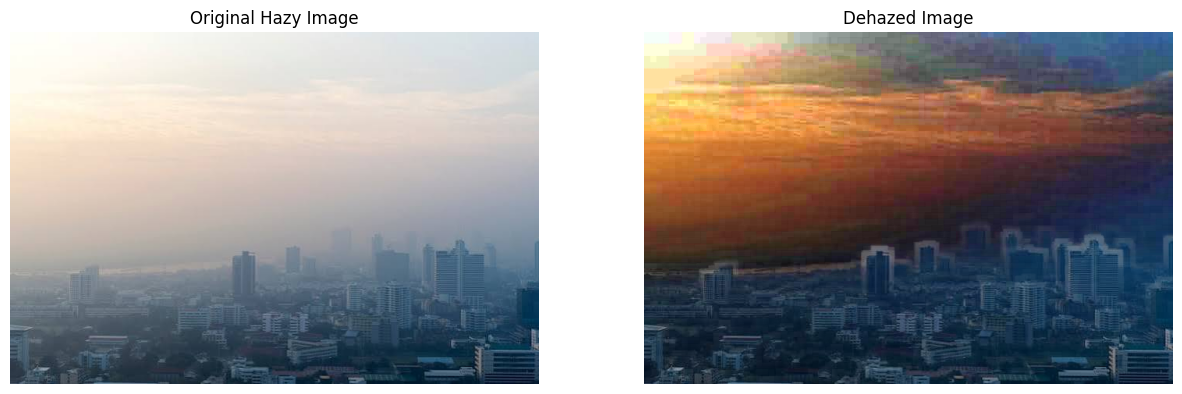

In [7]:
if hazy_image is not None:
    print("Applying dehazing algorithm...")
    dehazed_image = dehaze_image(hazy_image)

    if dehazed_image is not None:
        plt.figure(figsize=(15, 7))

        plt.subplot(1, 2, 1)
        plt.imshow(hazy_image)
        plt.title('Original Hazy Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(dehazed_image)
        plt.title('Dehazed Image')
        plt.axis('off')

        plt.show()
    else:
        print("Dehazing failed. Please ensure the image was loaded correctly.")
else:
    print("Cannot proceed with dehazing as no image was loaded.")